# 05 Improved Deep Model Notes

## 1. Week 5 goal
## 2. Improvement directions
## 3. Kaggle run record
## 4. Validation results
## 5. Comparison with week 4 model

## Improvement 1: add abstract text

The week 4 deep baseline only used news titles. Since the week 3 logistic regression baseline showed that title + abstract outperformed title-only text, the first improvement in week 5 is to incorporate abstract content into the deep model input.

## Improvement 2: add category information

Besides text content, category and subcategory provide structured information about the news item. These variables may help the deep model capture topical differences that are not fully represented by sparse text features alone.

## Final input design of week 5 improved model

The week 5 model uses three groups of input features:
1. title + abstract TF-IDF text features
2. standardized history length
3. standardized category and subcategory features

In [1]:
import pandas as pd
results_compare = pd.DataFrame([
    {"model": "TFIDF_title_LR", "auc": 0.579711, "logloss": 0.607928},
    {"model": "TFIDF_title_abstract_LR", "auc": 0.596899, "logloss": 0.613277},
    {"model": "LightGBM_tabular", "auc": 0.625116, "logloss": 0.167376},
    {"model": "PyTorch_deep_baseline", "auc": 0.583345, "logloss": 0.173230},
    {"model": "Improved_deep_model", "auc": 0.594895, "logloss": 0.170357},
])

results_compare

,model,auc,logloss
0,TFIDF_title_LR,0.579711,0.607928
1,TFIDF_title_abstract_LR,0.596899,0.613277
2,LightGBM_tabular,0.625116,0.167376
3,PyTorch_deep_baseline,0.583345,0.173230
4,Improved_deep_model,0.594895,0.170357


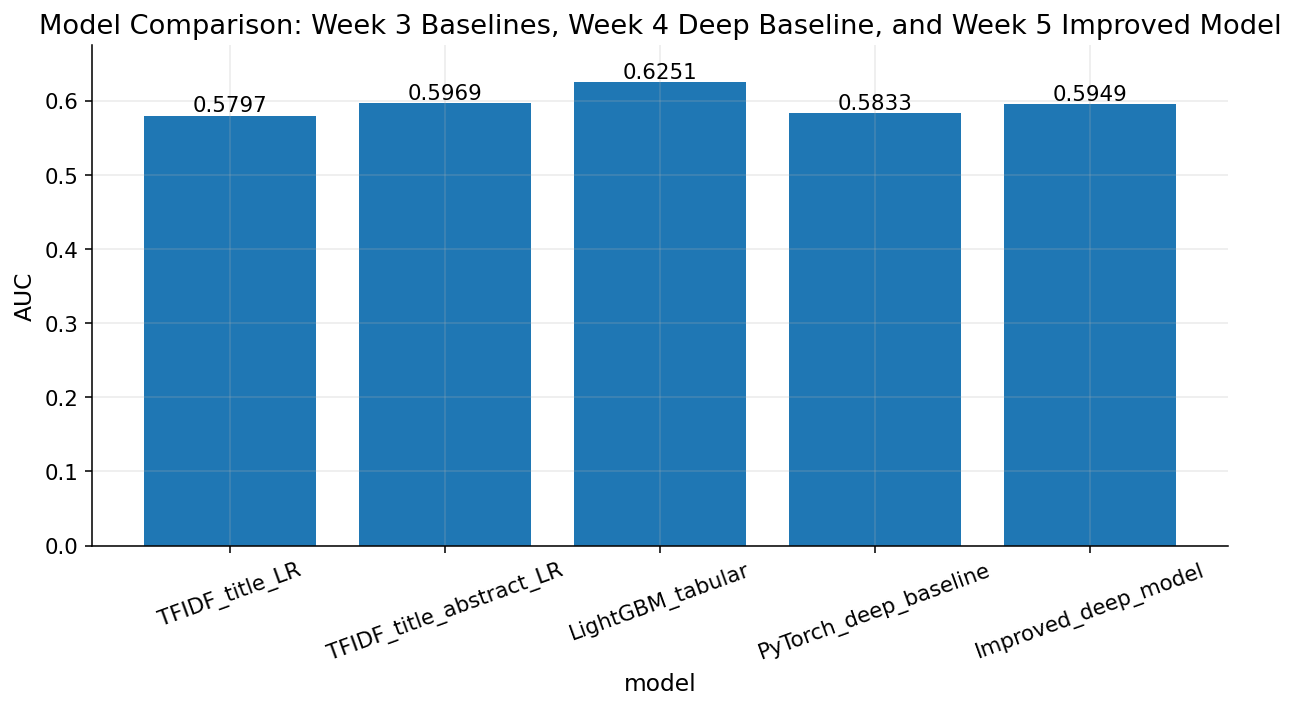

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (9, 5.2)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

fig, ax = plt.subplots()
bars = ax.bar(results_compare["model"], results_compare["auc"])

ax.set_title("Model Comparison: Week 3 Baselines, Week 4 Deep Baseline, and Week 5 Improved Model")
ax.set_xlabel("model")
ax.set_ylabel("AUC")
ax.set_ylim(0, max(results_compare["auc"]) * 1.08)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20)
plt.tight_layout()

save_path = BASE_DIR / "results" / "figures" / "week5_model_comparison_auc.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()

In [3]:
save_path = BASE_DIR / "results" / "tables" / "week5_improved_results.csv"
results_compare.to_csv(save_path, index=False)
print("saved:", save_path)

saved: ../results/tables/week5_improved_results.csv


## Result interpretation

The week 5 improved model extends the week 4 deep baseline by incorporating abstract text and category information. The comparison against week 3 and week 4 models is used to evaluate whether richer content features can improve the predictive performance of the neural click prediction model.